In [1]:
library(data.table)
library(igraph)
setwd("/srv/home/mlef0011/VDARK/")


Attaching package: 'igraph'


The following objects are masked from 'package:stats':

    decompose, spectrum


The following object is masked from 'package:base':

    union




In [16]:
K=31
KMER_MAX_FREQ <- 50
MIN_SHARED_KMERS <- 2
CLUSTER_SIZE_CAP <- 100
MEAN_WEIGHT_THRESHOLD <- 5

WD <- "/srv/home/mlef0011/VDARK/"
label     <- paste0("chr21_k", K)

label_write <- paste0(
    label,
    "_mkf", KMER_MAX_FREQ,
    "_msk", MIN_SHARED_KMERS,
    "_csc", CLUSTER_SIZE_CAP,
    "_mwt", MEAN_WEIGHT_THRESHOLD
)

In [17]:
snv_path = "/srv/home/mlef0011/rawdata/PCAWG_data/TCGA/snv_mnv/5dbf3203-ce73-41e4-bf9a-32fc856f73f5.consensus.20160830.somatic.snv_mnv.vcf.gz"
snv_df = fread(snv_path, data.table=F)
snv_df = snv_df[snv_df$FILTER == "." & snv_df$`#CHROM` == 21,]
bed <- data.frame(
    CHROM = snv_df$`#CHROM`,   # ou CHROM selon le nom de colonne exact après lecture
    START = snv_df$POS - 1L,
    END   = snv_df$POS
)

write.table(bed, "rawdata/SNV_positions_chr21_5dbf3203-ce73-41e4-bf9a-32fc856f73f5.bed", sep = "\t", quote = FALSE,
            row.names = FALSE, col.names = FALSE)

In [18]:
read_kmer_df <- fread(file.path(WD, paste0("rawdata/reads/read_kmer_association_",label,".tsv")))
read_kmer_df <- read_kmer_df[, if (.N <= KMER_MAX_FREQ) .SD, by = kmer]  

pairs <- read_kmer_df[, {
    ids <- read_ID
    if (length(ids) >= 2) {
        idx <- combn(length(ids), 2)
        data.table(read_ID.x = ids[idx[1,]], read_ID.y = ids[idx[2,]])
    }
}, by = kmer][, .(weight = .N), by = .(read_ID.x, read_ID.y)]

pairs <- pairs[weight >= MIN_SHARED_KMERS]
pairs <- pairs[read_ID.x != read_ID.y]
                             
G        <- graph_from_data_frame(pairs, directed = FALSE)
E(G)$weight <- pairs$weight
clusters <- get("components", envir = asNamespace("igraph"))(G)

big_clusters <- which(clusters$csize > CLUSTER_SIZE_CAP)

In [19]:
valid_clusters <- setdiff(seq_len(clusters$no), big_clusters)


edge_df <- as.data.table(igraph::as_data_frame(G, what = "edges"))
edge_df[, cluster := clusters$membership[from]]
cluster_weight <- edge_df[, .(mean_weight = mean(weight)), by = cluster]

valid_clusters <- intersect(valid_clusters, cluster_weight[mean_weight >= MEAN_WEIGHT_THRESHOLD, cluster])
length(valid_clusters)
   

[1] 17931

In [20]:
cluster_reads <- split(names(clusters$membership), clusters$membership)
cluster_reads <- cluster_reads[as.character(valid_clusters)]

In [26]:
pileup_tumour <- fread("/srv/home/mlef0011/VDARK/rawdata/read_names_SNV_positions_chr21_5dbf3203-ce73-41e4-bf9a-32fc856f73f5_tumour.pileup", header = FALSE,
                col.names = c("CHROM","POS","REF","DEPTH","BASES","QUALS","QNAMES"))

pileup_normal <- fread("/srv/home/mlef0011/VDARK/rawdata/read_names_SNV_positions_chr21_5dbf3203-ce73-41e4-bf9a-32fc856f73f5_normal.pileup", header = FALSE,
                col.names = c("CHROM","POS","REF","DEPTH","BASES","QUALS","QNAMES"))

In [22]:
eval_snv <- function(qnames_str, cluster_reads) {
    truth <- unique(strsplit(qnames_str, ",")[[1]])
    truth <- truth[truth != ""]
    n_truth <- length(truth)
    if (n_truth == 0) return(list(n_truth = 0, best_cluster = NA, kmer_in_best_cluster = 0,
                                  n_matched = NA, recall = NA, purity = NA, n_clusters_hit = 0,
                                  n_total_in_read_df = 0,  n_total_in_clusters = 0))

    overlaps <- vapply(cluster_reads, function(cl) length(intersect(cl, truth)), integer(1))
    n_clusters_hit <- sum(overlaps > 0)
    best_idx <- which.max(overlaps)
                       
    all_matched <- unique(unlist(lapply(cluster_reads, function(cl) intersect(cl, truth))))
    n_total_in_clusters <- length(all_matched)
    n_total_in_read_df = sum(truth %in% read_kmer_df$read_ID)                                  

    list(
        n_truth              = n_truth,
        best_cluster         = names(cluster_reads)[best_idx],
        kmer_in_best_cluster = length(cluster_reads[[best_idx]]),
        n_matched            = overlaps[best_idx],
        recall               = overlaps[best_idx] / n_truth,
        purity               = overlaps[best_idx] / length(cluster_reads[[best_idx]]),
        n_clusters_hit       = n_clusters_hit,
        n_total_in_clusters  = n_total_in_clusters,
        n_total_in_read_df   = n_total_in_read_df,
        recall_total         = n_total_in_clusters / n_truth
    )
}

In [23]:
results_tumour <- rbindlist(lapply(seq_len(nrow(pileup_tumour)), function(i) {
    res <- eval_snv(pileup_tumour$QNAMES[i], cluster_reads)
    data.table(CHROM = pileup_tumour$CHROM[i], POS = pileup_tumour$POS[i],
              n_truth = res$n_truth, best_cluster = res$best_cluster, kmer_in_best_cluster = res$kmer_in_best_cluster,
              n_matched = res$n_matched, recall = res$recall,
              purity = res$purity, n_clusters_hit = res$n_clusters_hit, 
              n_total_in_read_df = res$n_total_in_read_df, n_total_in_clusters = res$n_total_in_clusters)
}))

# Vue d'ensemble
summary(results_tumour$recall)
summary(results_tumour$purity)
table(results_tumour$n_clusters_hit)
mean(results_tumour$recall == 0, na.rm = TRUE)

write.table(results_tumour, paste0("/srv/home/mlef0011/VDARK/output/accuracy/SNV_recall_purity_clusters",label_write,"_tumour.tsv"), col.names=T, row.names=F, sep='\t', quote=F)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.1111  0.1842  0.2136  0.2963  0.7143 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.8000  0.9091  0.8293  1.0000  1.0000 


  0   1   2   3   4 
 11 183  19   7   1 

[1] 0.04977376

In [27]:
results_normal <- rbindlist(lapply(seq_len(nrow(pileup_normal)), function(i) {
    res <- eval_snv(pileup_normal$QNAMES[i], cluster_reads)
    data.table(CHROM = pileup_normal$CHROM[i], POS = pileup_normal$POS[i],
              n_truth = res$n_truth, best_cluster = res$best_cluster, kmer_in_best_cluster = res$kmer_in_best_cluster,
              n_matched = res$n_matched, recall = res$recall,
              purity = res$purity, n_clusters_hit = res$n_clusters_hit, 
              n_total_in_read_df = res$n_total_in_read_df, n_total_in_clusters = res$n_total_in_clusters)
}))

# Vue d'ensemble
summary(results_normal$recall)
summary(results_normal$purity)
table(results_normal$n_clusters_hit)
mean(results_normal$recall == 0, na.rm = TRUE)

write.table(results, paste0("/srv/home/mlef0011/VDARK/output/accuracy/SNV_recall_purity_clusters",label_write,"_normal.tsv"), col.names=T, row.names=F, sep='\t', quote=F)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
      0       0       0       0       0       0 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
      0       0       0       0       0       0 


  0 
221 

[1] 1

In [ ]:
# 3 - 5
results[which(results$purity == 0)]
#cluster_reads

In [60]:
# 2 - 5
results[which(results$purity == 0)]
#cluster_reads

CHROM,POS,n_truth,best_cluster,n_matched,recall,purity,n_clusters_hit,n_total_in_clusters
<int>,<int>,<int>,<chr>,<int>,<dbl>,<dbl>,<int>,<int>
21,18963527,37,2,0,0,0,0,0
21,20009909,31,2,0,0,0,0,0
21,20472948,47,2,0,0,0,0,0
21,20472949,46,2,0,0,0,0,0
21,20705215,25,2,0,0,0,0,0
21,21665227,31,2,0,0,0,0,0
21,23218360,33,2,0,0,0,0,0
21,25206120,40,2,0,0,0,0,0
21,29809260,50,2,0,0,0,0,0


In [47]:
results[which(results$purity == 0)]
#cluster_reads

CHROM,POS,n_truth,best_cluster,n_matched,recall,purity,n_clusters_hit,n_total_in_clusters
<int>,<int>,<int>,<chr>,<int>,<dbl>,<dbl>,<int>,<int>
21,18963527,37,3,0,0,0,0,0
21,19553698,42,3,0,0,0,0,0
21,19652291,40,3,0,0,0,0,0
21,20009909,31,3,0,0,0,0,0
21,20472948,47,3,0,0,0,0,0
21,20472949,46,3,0,0,0,0,0
21,20705215,25,3,0,0,0,0,0
21,21665227,31,3,0,0,0,0,0
21,23218360,33,3,0,0,0,0,0


[1] 221

[1] 14251

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   3.00    6.00    8.00   11.87   15.00   88.00 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  2.000   3.000   4.000   5.526   6.000  94.000 

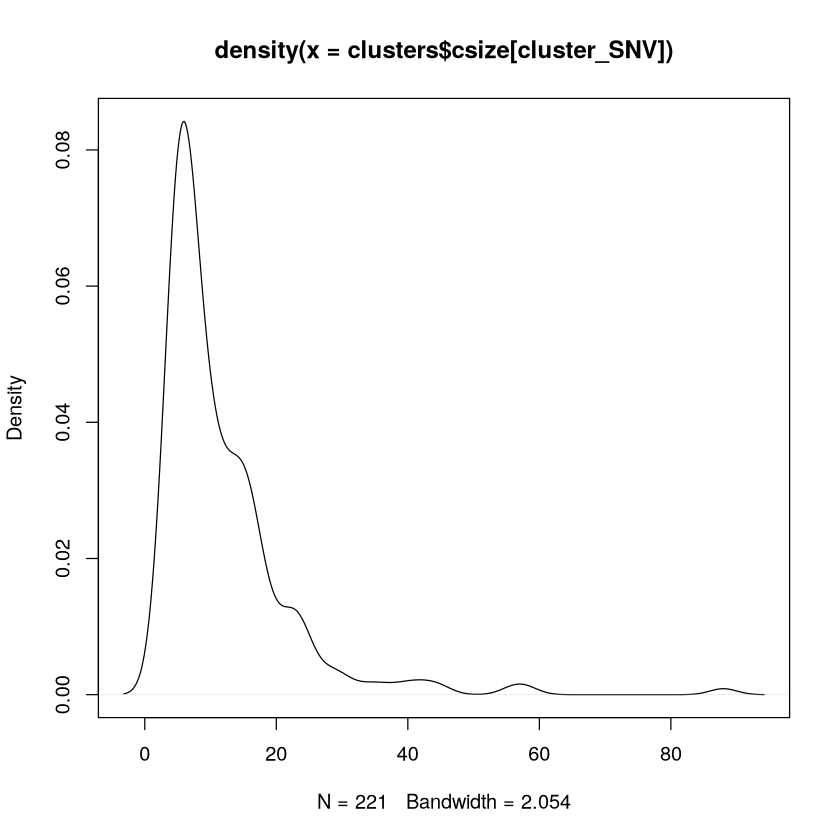

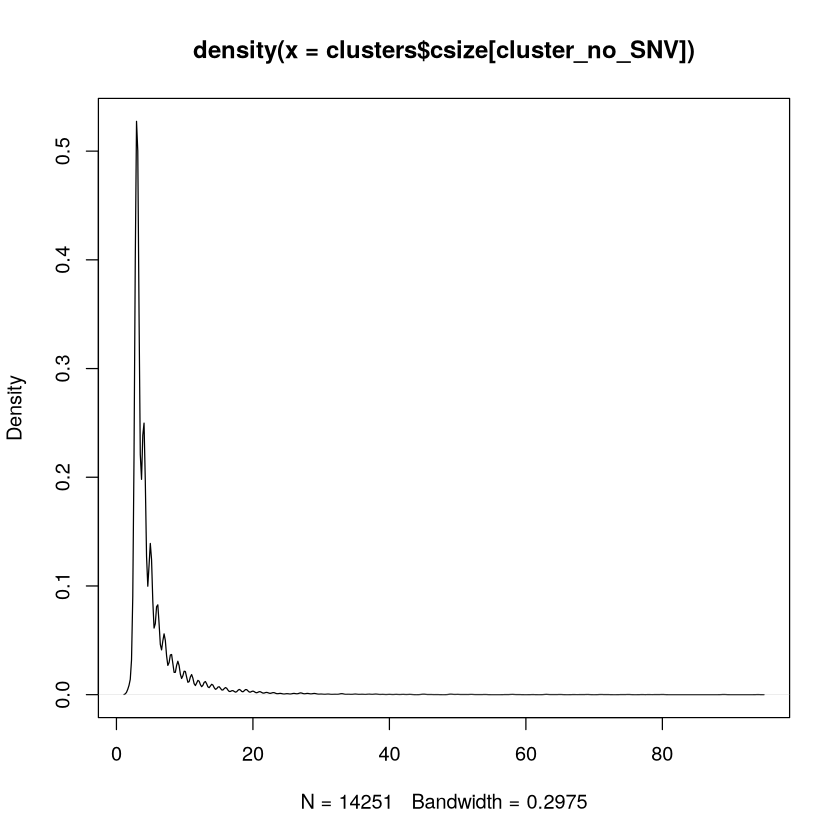

In [9]:
cluster_SNV = as.numeric(results$best_cluster)
cluster_no_SNV = as.numeric(setdiff(valid_clusters,results$best_cluster))

length(cluster_SNV)
length(cluster_no_SNV)

summary(clusters$csize[cluster_SNV])
summary(clusters$csize[cluster_no_SNV])

plot(density(clusters$csize[cluster_SNV]))
plot(density(clusters$csize[cluster_no_SNV]))

In [10]:
# Récupérer les edges avec leur poids et le cluster auquel ils appartiennent
edge_df <- as.data.table(igraph::as_data_frame(G, what = "edges"))
edge_df[, cluster := clusters$membership[from]]   # from/to sont dans le même cluster par définition

edge_stats <- edge_df[, .(
    mean_weight = mean(weight),
    max_weight  = max(weight),
    n_edges     = .N
), by = cluster]

# Restreindre aux clusters valides (comme pour ton analyse précédente)
edge_stats <- edge_stats[cluster %in% valid_clusters]

# Étiqueter signal vs bruit
edge_stats[, has_snv := cluster %in% cluster_SNV]

# Comparaison
edge_stats[, .(
    n_clusters   = .N,
    mean_weight  = mean(mean_weight),
    median_weight= median(mean_weight),
    mean_maxw    = mean(max_weight)
), by = has_snv]

summary(edge_stats[has_snv == TRUE,  mean_weight])
summary(edge_stats[has_snv == FALSE, mean_weight])

has_snv,n_clusters,mean_weight,median_weight,mean_maxw
<lgl>,<int>,<dbl>,<dbl>,<dbl>
TRUE,201,17.47095,17,29.87562
FALSE,14251,12.65793,11,17.59827


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   7.00   14.38   17.00   17.47   20.00   37.50 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   7.00    8.40   11.00   12.66   15.00  112.00 